**Clustering**

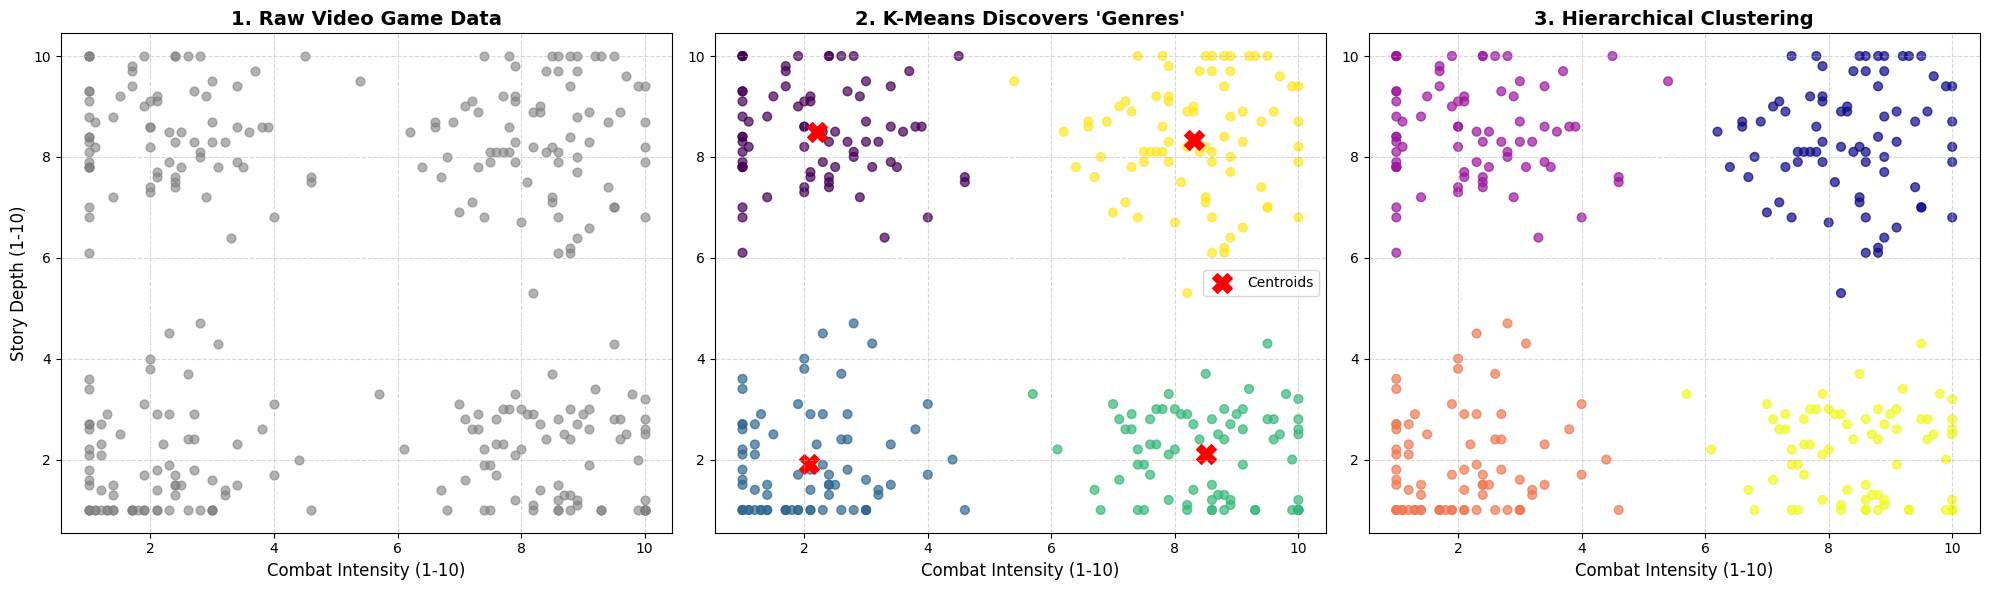

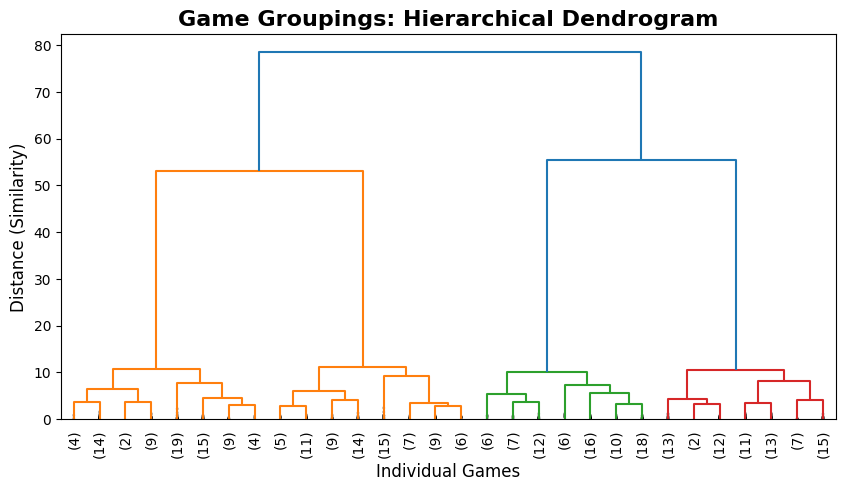

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage


df = pd.read_csv('video_game_data.csv')

# Extract just our two numeric columns as a NumPy array for scikit-learn
X = df[['Combat_Intensity', 'Story_Depth']].values 


# K-MEANS CLUSTERING
# We ask K-Means to find 4 distinct game profiles
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_ 

# HIERARCHICAL CLUSTERING
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X)


# VISUALIZATION 
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot A: Raw Data
axes[0].scatter(X[:, 0], X[:, 1], s=40, color='gray', alpha=0.6)
axes[0].set_title("1. Raw Video Game Data", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Combat Intensity (1-10)", fontsize=12)
axes[0].set_ylabel("Story Depth (1-10)", fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot B: K-Means Result
axes[1].scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis', s=40, alpha=0.7)
axes[1].scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
axes[1].set_title("2. K-Means Discovers 'Genres'", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Combat Intensity (1-10)", fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

# Plot C: Hierarchical Result
axes[2].scatter(X[:, 0], X[:, 1], c=hierarchical_labels, cmap='plasma', s=40, alpha=0.7)
axes[2].set_title("3. Hierarchical Clustering", fontsize=14, fontweight='bold')
axes[2].set_xlabel("Combat Intensity (1-10)", fontsize=12)
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# THE DENDROGRAM 
plt.figure(figsize=(10, 5))
plt.title("Game Groupings: Hierarchical Dendrogram", fontsize=16, fontweight='bold')
plt.xlabel("Individual Games", fontsize=12)
plt.ylabel("Distance (Similarity)", fontsize=12)

# Calculate the linkage matrix
linked = linkage(X, method='ward')

# Draw the dendrogram
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.show()